In [1]:
# libraries and settings

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

# reproducibility
RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

try:
    import torch

    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

except ImportError:
    torch = None

RANDOM_STATE

42

In [2]:
# load minute-level features

MINUTE_FEATURES_FILE = "minute_features.pkl"

minute_agg = pd.read_pickle(MINUTE_FEATURES_FILE)

print("minute_agg shape:", minute_agg.shape)

display(minute_agg.head())
display(minute_agg.tail())

minute_agg shape: (390, 33)


,minute,mid_open,mid_close,mid_mean,spread_mean,spread_std,spread_max,relative_spread_mean,ask_depth_mean,bid_depth_mean,imbalance_1_mean,imbalance_3_mean,imbalance_5_mean,imbalance_10_mean,ofi_sum,ofi_mean,ofi_std,event_count,event_size_total,trade_volume,n_new_order,n_partial_cancel,n_full_deletion,n_execution,price_change,depth_imbalance,execution_ratio,mid_return_1m,mid_log_return_1m,hour,minute_of_hour,clock,mid_ma10
0,570,30.970,31.030,31.006870,0.015846,0.006937,0.05,0.000511,27408.517256,9317.603538,-0.244671,-0.454135,-0.460288,-0.407132,39829.0,17.182485,634.651659,2318,960665,100726,1153,8,819,338,0.060,-0.492590,0.145815,0.000,0.000000,9,30,09:30,31.030000
1,571,31.030,31.075,31.048728,0.013597,0.004949,0.03,0.000438,28868.341737,9319.614566,-0.114945,-0.334294,-0.493083,-0.371347,81633.0,22.866387,364.017803,3570,1109998,113923,1699,43,1421,407,0.045,-0.511908,0.114006,0.045,0.001449,9,31,09:31,31.052500
2,572,31.075,31.055,31.073450,0.013584,0.004824,0.03,0.000437,13492.869452,12439.499347,0.040813,0.099380,-0.048756,-0.295330,-12213.0,-7.971932,405.491307,1532,542227,33473,739,4,637,152,-0.020,-0.040620,0.099217,-0.020,-0.000644,9,32,09:32,31.053333
3,573,31.055,31.060,31.095780,0.014345,0.004958,0.02,0.000461,20437.152461,14443.600515,0.110257,-0.007885,-0.148665,-0.330051,-8944.0,-2.876809,799.160711,3109,1152591,78816,1518,25,1341,225,0.005,-0.171830,0.072371,0.005,0.000161,9,33,09:33,31.055000
4,574,31.060,31.005,30.993534,0.014124,0.004923,0.02,0.000456,14361.180905,19741.444891,-0.110701,0.037904,0.080057,0.162996,-43206.0,-14.474372,379.281401,2985,1025656,43411,1424,52,1331,178,-0.055,0.157767,0.059631,-0.055,-0.001772,9,34,09:34,31.045000


,minute,mid_open,mid_close,mid_mean,spread_mean,spread_std,spread_max,relative_spread_mean,ask_depth_mean,bid_depth_mean,imbalance_1_mean,imbalance_3_mean,imbalance_5_mean,imbalance_10_mean,ofi_sum,ofi_mean,ofi_std,event_count,event_size_total,trade_volume,n_new_order,n_partial_cancel,n_full_deletion,n_execution,price_change,depth_imbalance,execution_ratio,mid_return_1m,mid_log_return_1m,hour,minute_of_hour,clock,mid_ma10
385,955,30.085,30.105,30.099262,0.010304,0.001717,0.02,0.000342,127788.607320,182422.879653,0.170992,0.159628,0.173943,0.190675,162314.0,50.345533,945.012819,3224,1721103,48245,1569,76,1419,160,0.02,0.176119,0.049628,0.02,0.000665,15,55,15:55,30.097
386,956,30.105,30.105,30.105000,0.010000,0.000000,0.01,0.000332,132832.881317,169491.537320,0.046033,0.072912,0.121752,0.127655,17125.0,7.939268,629.958143,2157,1072080,32747,1036,85,940,96,0.00,0.121256,0.044506,0.00,0.000000,15,56,15:56,30.093
387,957,30.105,30.115,30.112626,0.012707,0.004444,0.02,0.000422,158206.741357,185680.322846,-0.191013,-0.033654,0.081129,0.157278,103296.0,18.894458,1876.177773,5467,4953578,263998,2495,128,2379,465,0.01,0.079891,0.085056,0.01,0.000332,15,57,15:57,30.092
388,958,30.115,30.115,30.114985,0.010029,0.000541,0.02,0.000333,152651.204301,156028.607038,-0.580002,-0.143014,0.010403,0.118308,-18076.0,-8.834800,1335.067396,2046,1408791,57900,948,71,850,177,0.00,0.010941,0.086510,0.00,0.000000,15,58,15:58,30.094
389,959,30.115,30.135,30.129419,0.010743,0.002623,0.02,0.000357,179653.619359,189631.654282,0.016366,0.045096,0.034676,-0.017422,349923.0,55.800191,3022.661394,6271,8269486,569818,2681,140,2561,889,0.02,0.027020,0.141764,0.02,0.000664,15,59,15:59,30.098


In [3]:
# time order check

time_order_report = {
    "minute_column_exists": "minute" in minute_agg.columns,
    "minute_is_monotonic_increasing": minute_agg["minute"].is_monotonic_increasing,
    "duplicate_minute_count": int(minute_agg["minute"].duplicated().sum()),
    "first_minute": int(minute_agg["minute"].iloc[0]),
    "last_minute": int(minute_agg["minute"].iloc[-1]),
    "total_minutes": int(minute_agg["minute"].nunique())
}

display(pd.DataFrame([time_order_report]))

assert time_order_report["minute_column_exists"], "minute kolonu bulunamadı."
assert time_order_report["minute_is_monotonic_increasing"], "minute kolonu zaman sırasına göre artmıyor."
assert time_order_report["duplicate_minute_count"] == 0, "Tekrarlayan minute değeri var."

print("Zaman sırası kontrolü geçti.")

,minute_column_exists,minute_is_monotonic_increasing,duplicate_minute_count,first_minute,last_minute,total_minutes
0,True,True,0,570,959,390


Zaman sırası kontrolü geçti.


In [ ]:
# target creation

minute_agg["future_mid_close"] = minute_agg["mid_close"].shift(-1)

minute_agg["future_mid_return"] = (
    minute_agg["future_mid_close"] - minute_agg["mid_close"]
)

# Since the last minute does not have a next minute, the target cannot be created for it.
target_data = minute_agg.dropna(subset=["future_mid_return"]).copy()
target_data = target_data.reset_index(drop=True)

print("Original minute_agg shape:", minute_agg.shape)
print("Target data shape:", target_data.shape)

display(target_data[[
    "minute",
    "mid_close",
    "future_mid_close",
    "future_mid_return"
]].head())

display(target_data[[
    "minute",
    "mid_close",
    "future_mid_close",
    "future_mid_return"
]].tail())

Original minute_agg shape: (390, 35)
Target data shape: (389, 35)


,minute,mid_close,future_mid_close,future_mid_return
0,570,31.030,31.075,0.045
1,571,31.075,31.055,-0.020
2,572,31.055,31.060,0.005
3,573,31.060,31.005,-0.055
4,574,31.005,31.055,0.050


,minute,mid_close,future_mid_close,future_mid_return
384,954,30.085,30.105,0.02
385,955,30.105,30.105,0.00
386,956,30.105,30.115,0.01
387,957,30.115,30.115,0.00
388,958,30.115,30.135,0.02


In [5]:
# threshold analysis

thresholds = [0.001, 0.003, 0.005, 0.008, 0.010, 0.015]

threshold_results = []

for threshold in thresholds:

    temp_target = np.select(
        [
            target_data["future_mid_return"] <= -threshold,
            target_data["future_mid_return"] >= threshold
        ],
        [
            "down",
            "up"
        ],
        default="flat"
    )

    class_counts = pd.Series(temp_target).value_counts()

    threshold_results.append({
        "threshold": threshold,
        "threshold_cent": f"{threshold * 100:.1f}¢",
        "down": class_counts.get("down", 0),
        "flat": class_counts.get("flat", 0),
        "up": class_counts.get("up", 0),
        "down_ratio": class_counts.get("down", 0) / len(target_data),
        "flat_ratio": class_counts.get("flat", 0) / len(target_data),
        "up_ratio": class_counts.get("up", 0) / len(target_data)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,threshold,threshold_cent,down,flat,up,down_ratio,flat_ratio,up_ratio
0,0.001,0.1¢,158,107,124,0.406170,0.275064,0.318766
1,0.003,0.3¢,158,107,124,0.406170,0.275064,0.318766
2,0.005,0.5¢,158,107,124,0.406170,0.275064,0.318766
3,0.008,0.8¢,158,108,123,0.406170,0.277635,0.316195
4,0.010,1.0¢,122,179,88,0.313625,0.460154,0.226221
5,0.015,1.5¢,93,237,59,0.239075,0.609254,0.151671


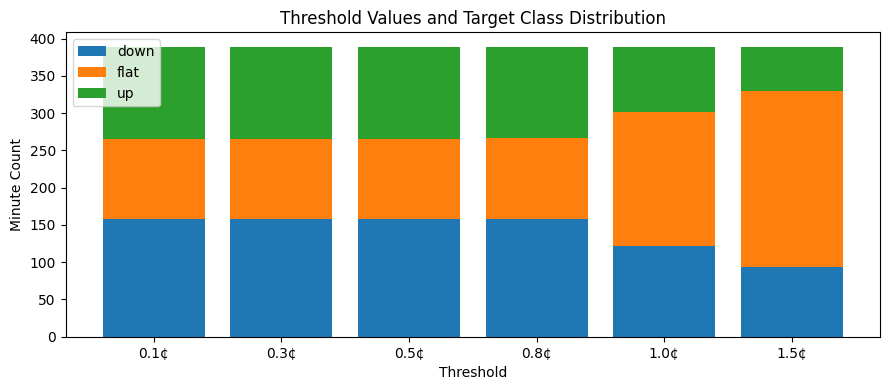

In [6]:
# threshold-based class distribution plot

x_pos = np.arange(len(threshold_df))

plt.figure(figsize=(9, 4))

plt.bar(
    x_pos,
    threshold_df["down"],
    label="down"
)

plt.bar(
    x_pos,
    threshold_df["flat"],
    bottom=threshold_df["down"],
    label="flat"
)

plt.bar(
    x_pos,
    threshold_df["up"],
    bottom=threshold_df["down"] + threshold_df["flat"],
    label="up"
)

plt.xticks(x_pos, threshold_df["threshold_cent"])

plt.title("Threshold Values and Target Class Distribution")
plt.xlabel("Threshold")
plt.ylabel("Minute Count")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# final target creation

TARGET_HORIZON_MINUTES = 1
TICK_SIZE = 0.01

# Final threshold selection:
# We use a 1-tick threshold.
# Thus, if the price increases by at least 1 tick, it is labeled as "up";
# if it decreases by at least 1 tick, it is labeled as "down";
# smaller movements are labeled as "flat".

TARGET_THRESHOLD = TICK_SIZE

CLASS_LABELS = {
    0: "down",
    1: "flat",
    2: "up"
}

LABEL_TO_ID = {
    "down": 0,
    "flat": 1,
    "up": 2
}

target_data["target"] = np.select(
    [
        target_data["future_mid_return"] <= -TARGET_THRESHOLD,
        target_data["future_mid_return"] >= TARGET_THRESHOLD
    ],
    [
        LABEL_TO_ID["down"],
        LABEL_TO_ID["up"]
    ],
    default=LABEL_TO_ID["flat"]
)

target_data["target_label"] = target_data["target"].map(CLASS_LABELS)

print(f"Target horizon: t + {TARGET_HORIZON_MINUTES} minute")
print(f"Target threshold: {TARGET_THRESHOLD:.4f} USD")
print(f"Target threshold in ticks: {TARGET_THRESHOLD / TICK_SIZE:.1f}")

display(target_data[[
    "minute",
    "mid_close",
    "future_mid_close",
    "future_mid_return",
    "target",
    "target_label"
]].head(10))

Target horizon: t + 1 minute
Target threshold: 0.0100 USD
Target threshold in ticks: 1.0


,minute,mid_close,future_mid_close,future_mid_return,target,target_label
0,570,31.030,31.075,0.045,2,up
1,571,31.075,31.055,-0.020,0,down
2,572,31.055,31.060,0.005,1,flat
3,573,31.060,31.005,-0.055,0,down
4,574,31.005,31.055,0.050,2,up
5,575,31.055,31.045,-0.010,1,flat
6,576,31.045,31.025,-0.020,0,down
7,577,31.025,30.995,-0.030,0,down
8,578,30.995,30.935,-0.060,0,down
9,579,30.935,30.965,0.030,2,up


In [8]:
# final target distribution

target_distribution = (
    target_data["target_label"]
    .value_counts()
    .reindex(["down", "flat", "up"], fill_value=0)
    .rename_axis("target_label")
    .reset_index(name="count")
)

target_distribution["ratio_pct"] = (
    target_distribution["count"] / target_distribution["count"].sum() * 100
).round(2)

display(target_distribution)

class_imbalance_ratio = (
    target_distribution["count"].max() / target_distribution["count"].min()
)

print(f"Class imbalance ratio: {class_imbalance_ratio:.2f}x")

,target_label,count,ratio_pct
0,down,122,31.36
1,flat,179,46.02
2,up,88,22.62


Class imbalance ratio: 2.03x


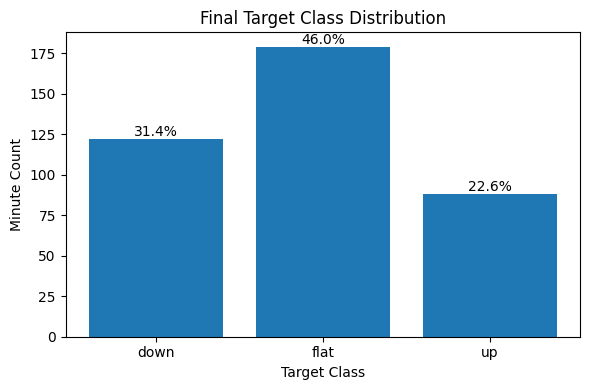

In [9]:
# final target distribution plot

plt.figure(figsize=(6, 4))

plt.bar(
    target_distribution["target_label"],
    target_distribution["count"]
)

plt.title("Final Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Minute Count")

for i, row in target_distribution.iterrows():
    plt.text(
        i,
        row["count"],
        f'{row["ratio_pct"]:.1f}%',
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [10]:
# lag and rolling feature settings

LAG_WINDOWS = [1, 2, 3, 5, 10, 15, 30]
ROLLING_WINDOWS = [3, 5, 10, 15, 30]

base_signal_cols = [
    "mid_open",
    "mid_close",
    "mid_mean",
    "price_change",

    "spread_mean",
    "spread_std",
    "spread_max",
    "relative_spread_mean",

    "ask_depth_mean",
    "bid_depth_mean",
    "depth_imbalance",

    "imbalance_1_mean",
    "imbalance_3_mean",
    "imbalance_5_mean",
    "imbalance_10_mean",

    "ofi_sum",
    "ofi_mean",
    "ofi_std",

    "event_count",
    "event_size_total",
    "trade_volume",

    "n_new_order",
    "n_partial_cancel",
    "n_full_deletion",
    "n_execution",
    "execution_ratio",

    "mid_return_1m",
    "mid_log_return_1m"
]

base_signal_cols = [
    col for col in base_signal_cols
    if col in target_data.columns
]

print("Lag windows:", LAG_WINDOWS)
print("Rolling windows:", ROLLING_WINDOWS)
print("Base signal feature count:", len(base_signal_cols))

print("\nBase signal columns:")
for col in base_signal_cols:
    print("-", col)

Lag windows: [1, 2, 3, 5, 10, 15, 30]
Rolling windows: [3, 5, 10, 15, 30]
Base signal feature count: 28

Base signal columns:
- mid_open
- mid_close
- mid_mean
- price_change
- spread_mean
- spread_std
- spread_max
- relative_spread_mean
- ask_depth_mean
- bid_depth_mean
- depth_imbalance
- imbalance_1_mean
- imbalance_3_mean
- imbalance_5_mean
- imbalance_10_mean
- ofi_sum
- ofi_mean
- ofi_std
- event_count
- event_size_total
- trade_volume
- n_new_order
- n_partial_cancel
- n_full_deletion
- n_execution
- execution_ratio
- mid_return_1m
- mid_log_return_1m


In [11]:
# lag and rolling feature generation

model_data = target_data.copy()

for col in base_signal_cols:

    # lag features
    for lag in LAG_WINDOWS:
        model_data[f"{col}_lag_{lag}"] = model_data[col].shift(lag)

    # rolling features use only past values
    past_values = model_data[col].shift(1)

    for window in ROLLING_WINDOWS:
        model_data[f"{col}_roll_mean_{window}"] = past_values.rolling(window).mean()
        model_data[f"{col}_roll_std_{window}"] = past_values.rolling(window).std()
        model_data[f"{col}_roll_min_{window}"] = past_values.rolling(window).min()
        model_data[f"{col}_roll_max_{window}"] = past_values.rolling(window).max()

print("Target data shape:", target_data.shape)
print("Model data shape after lag/rolling:", model_data.shape)

display(model_data.head())

Target data shape: (389, 37)
Model data shape after lag/rolling: (389, 793)


,minute,mid_open,mid_close,mid_mean,spread_mean,spread_std,spread_max,relative_spread_mean,ask_depth_mean,bid_depth_mean,imbalance_1_mean,imbalance_3_mean,imbalance_5_mean,imbalance_10_mean,ofi_sum,ofi_mean,ofi_std,event_count,event_size_total,trade_volume,n_new_order,n_partial_cancel,n_full_deletion,n_execution,price_change,depth_imbalance,execution_ratio,mid_return_1m,mid_log_return_1m,hour,minute_of_hour,clock,mid_ma10,future_mid_close,future_mid_return,target,target_label,mid_open_lag_1,mid_open_lag_2,mid_open_lag_3,mid_open_lag_5,mid_open_lag_10,mid_open_lag_15,mid_open_lag_30,mid_open_roll_mean_3,mid_open_roll_std_3,mid_open_roll_min_3,mid_open_roll_max_3,mid_open_roll_mean_5,mid_open_roll_std_5,...,mid_return_1m_lag_10,mid_return_1m_lag_15,mid_return_1m_lag_30,mid_return_1m_roll_mean_3,mid_return_1m_roll_std_3,mid_return_1m_roll_min_3,mid_return_1m_roll_max_3,mid_return_1m_roll_mean_5,mid_return_1m_roll_std_5,mid_return_1m_roll_min_5,mid_return_1m_roll_max_5,mid_return_1m_roll_mean_10,mid_return_1m_roll_std_10,mid_return_1m_roll_min_10,mid_return_1m_roll_max_10,mid_return_1m_roll_mean_15,mid_return_1m_roll_std_15,mid_return_1m_roll_min_15,mid_return_1m_roll_max_15,mid_return_1m_roll_mean_30,mid_return_1m_roll_std_30,mid_return_1m_roll_min_30,mid_return_1m_roll_max_30,mid_log_return_1m_lag_1,mid_log_return_1m_lag_2,mid_log_return_1m_lag_3,mid_log_return_1m_lag_5,mid_log_return_1m_lag_10,mid_log_return_1m_lag_15,mid_log_return_1m_lag_30,mid_log_return_1m_roll_mean_3,mid_log_return_1m_roll_std_3,mid_log_return_1m_roll_min_3,mid_log_return_1m_roll_max_3,mid_log_return_1m_roll_mean_5,mid_log_return_1m_roll_std_5,mid_log_return_1m_roll_min_5,mid_log_return_1m_roll_max_5,mid_log_return_1m_roll_mean_10,mid_log_return_1m_roll_std_10,mid_log_return_1m_roll_min_10,mid_log_return_1m_roll_max_10,mid_log_return_1m_roll_mean_15,mid_log_return_1m_roll_std_15,mid_log_return_1m_roll_min_15,mid_log_return_1m_roll_max_15,mid_log_return_1m_roll_mean_30,mid_log_return_1m_roll_std_30,mid_log_return_1m_roll_min_30,mid_log_return_1m_roll_max_30
0,570,30.970,31.030,31.006870,0.015846,0.006937,0.05,0.000511,27408.517256,9317.603538,-0.244671,-0.454135,-0.460288,-0.407132,39829.0,17.182485,634.651659,2318,960665,100726,1153,8,819,338,0.060,-0.492590,0.145815,0.000,0.000000,9,30,09:30,31.030000,31.075,0.045,2,up,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,571,31.030,31.075,31.048728,0.013597,0.004949,0.03,0.000438,28868.341737,9319.614566,-0.114945,-0.334294,-0.493083,-0.371347,81633.0,22.866387,364.017803,3570,1109998,113923,1699,43,1421,407,0.045,-0.511908,0.114006,0.045,0.001449,9,31,09:31,31.052500,31.055,-0.020,0,down,30.970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,572,31.075,31.055,31.073450,0.013584,0.004824,0.03,0.000437,13492.869452,12439.499347,0.040813,0.099380,-0.048756,-0.295330,-12213.0,-7.971932,405.491307,1532,542227,33473,739,4,637,152,-0.020,-0.040620,0.099217,-0.020,-0.000644,9,32,09:32,31.053333,31.060,0.005,1,flat,31.030,30.970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001449,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,573,31.055,31.060,31.095780,0.014345,0.004958,0.02,0.000461,20437.152461,14443.600515,0.110257,-0.007885,-0.148665,-0.330051,-8944.0,-2.876809,799.160711,3109,1152591,78816,1518,25,1341,225,0.005,-0.171830,0.072371,0.005,0.000161,9,33,09:33,31.055000,31.005,-0.055,0,down,31.075,31.030,30.97,NaN,NaN,NaN,NaN,31.025000,0.052678,

In [12]:
# final modeling dataset

contemporaneous_cols = base_signal_cols.copy()

model_feature_cols = contemporaneous_cols.copy()

for col in base_signal_cols:

    for lag in LAG_WINDOWS:
        feature_name = f"{col}_lag_{lag}"

        if feature_name in model_data.columns:
            model_feature_cols.append(feature_name)

    for window in ROLLING_WINDOWS:
        for stat in ["mean", "std", "min", "max"]:
            feature_name = f"{col}_roll_{stat}_{window}"

            if feature_name in model_data.columns:
                model_feature_cols.append(feature_name)

required_cols = model_feature_cols + ["target", "target_label"]

missing_cols = [
    col for col in required_cols
    if col not in model_data.columns
]

if len(missing_cols) > 0:
    raise KeyError(f"Eksik kolonlar var: {missing_cols}")

rows_before_drop = len(model_data)

model_df = (
    model_data
    .dropna(subset=required_cols)
    .copy()
    .reset_index(drop=True)
)

rows_after_drop = len(model_df)

print("Rows before lag/rolling NaN drop:", rows_before_drop)
print("Rows after lag/rolling NaN drop :", rows_after_drop)
print("Dropped rows:", rows_before_drop - rows_after_drop)

print("\nTotal model feature count:", len(model_feature_cols))
print("model_df shape:", model_df.shape)

display(model_df.head())

Rows before lag/rolling NaN drop: 389
Rows after lag/rolling NaN drop : 359
Dropped rows: 30

Total model feature count: 784
model_df shape: (359, 793)


,minute,mid_open,mid_close,mid_mean,spread_mean,spread_std,spread_max,relative_spread_mean,ask_depth_mean,bid_depth_mean,imbalance_1_mean,imbalance_3_mean,imbalance_5_mean,imbalance_10_mean,ofi_sum,ofi_mean,ofi_std,event_count,event_size_total,trade_volume,n_new_order,n_partial_cancel,n_full_deletion,n_execution,price_change,depth_imbalance,execution_ratio,mid_return_1m,mid_log_return_1m,hour,minute_of_hour,clock,mid_ma10,future_mid_close,future_mid_return,target,target_label,mid_open_lag_1,mid_open_lag_2,mid_open_lag_3,mid_open_lag_5,mid_open_lag_10,mid_open_lag_15,mid_open_lag_30,mid_open_roll_mean_3,mid_open_roll_std_3,mid_open_roll_min_3,mid_open_roll_max_3,mid_open_roll_mean_5,mid_open_roll_std_5,...,mid_return_1m_lag_10,mid_return_1m_lag_15,mid_return_1m_lag_30,mid_return_1m_roll_mean_3,mid_return_1m_roll_std_3,mid_return_1m_roll_min_3,mid_return_1m_roll_max_3,mid_return_1m_roll_mean_5,mid_return_1m_roll_std_5,mid_return_1m_roll_min_5,mid_return_1m_roll_max_5,mid_return_1m_roll_mean_10,mid_return_1m_roll_std_10,mid_return_1m_roll_min_10,mid_return_1m_roll_max_10,mid_return_1m_roll_mean_15,mid_return_1m_roll_std_15,mid_return_1m_roll_min_15,mid_return_1m_roll_max_15,mid_return_1m_roll_mean_30,mid_return_1m_roll_std_30,mid_return_1m_roll_min_30,mid_return_1m_roll_max_30,mid_log_return_1m_lag_1,mid_log_return_1m_lag_2,mid_log_return_1m_lag_3,mid_log_return_1m_lag_5,mid_log_return_1m_lag_10,mid_log_return_1m_lag_15,mid_log_return_1m_lag_30,mid_log_return_1m_roll_mean_3,mid_log_return_1m_roll_std_3,mid_log_return_1m_roll_min_3,mid_log_return_1m_roll_max_3,mid_log_return_1m_roll_mean_5,mid_log_return_1m_roll_std_5,mid_log_return_1m_roll_min_5,mid_log_return_1m_roll_max_5,mid_log_return_1m_roll_mean_10,mid_log_return_1m_roll_std_10,mid_log_return_1m_roll_min_10,mid_log_return_1m_roll_max_10,mid_log_return_1m_roll_mean_15,mid_log_return_1m_roll_std_15,mid_log_return_1m_roll_min_15,mid_log_return_1m_roll_max_15,mid_log_return_1m_roll_mean_30,mid_log_return_1m_roll_std_30,mid_log_return_1m_roll_min_30,mid_log_return_1m_roll_max_30
0,600,30.885,30.815,30.835212,0.014353,0.005530,0.03,0.000465,32824.956917,23607.855755,-0.160153,-0.205123,-0.176975,-0.154065,-121900.0,-25.744456,492.695370,4735,2034700,82237,2342,19,2045,329,-0.07,-0.163329,0.069483,-0.07,-0.002269,10,0,10:00,30.893,30.785,-0.03,0,down,30.905,30.895,30.895,30.925,30.925,30.995,30.970,30.898333,0.005774,30.895,30.905,30.907,0.013038,...,-0.02,-0.04,0.000,-0.003333,0.015275,-0.02,0.01,-0.008,0.013038,-0.02,0.01,-0.004,0.016465,-0.02,0.02,-0.007333,0.017099,-0.04,0.02,-0.004833,0.025444,-0.06,0.05,-0.000647,0.000324,0.000000,-0.000323,-0.000647,-0.001291,0.000000,-0.000108,0.000494,-0.000647,0.000324,-0.000259,0.000422,-0.000647,0.000324,-0.000129,0.000533,-0.000647,0.000647,-0.000237,0.000553,-0.001291,0.000647,-0.000156,0.000821,-0.001938,0.001611
1,601,30.815,30.785,30.802364,0.013313,0.004708,0.02,0.000432,32973.961183,38181.424677,0.229252,0.193269,0.073428,-0.117912,-47503.0,-21.951479,418.168737,2164,865804,38198,1090,10,922,142,-0.03,0.073184,0.065619,-0.03,-0.000974,10,1,10:01,30.883,30.765,-0.02,0,down,30.885,30.905,30.895,30.915,30.905,30.955,31.030,30.895000,0.010000,30.885,30.905,30.899,0.011402,...,-0.02,-0.01,0.045,-0.026667,0.040415,-0.07,0.01,-0.020,0.030822,-0.07,0.01,-0.009,0.026437,-0.07,0.02,-0.009333,0.022190,-0.07,0.02,-0.007167,0.028060,-0.07,0.05,-0.002269,-0.000647,0.000324,-0.000647,-0.000647,-0.000323,0.001449,-0.000864,0.001310,-0.002269,0.000324,-0.000648,0.000999,-0.002269,0.000324,-0.000292,0.000856,-0.002269,0.000647,-0.000302,0.000719,-0.002269,0.000647,-0.000232,0.000906,-0.002269,0.001611
2,602,30.785,30.765,30.783377,0.011774,0.003821,0.02,0.000382,51552.850716,54422.674847,0.044643,0.060605,0.038961,-0.085354,-84651.0,-43.277607,580.001979,1956,992787,29994,1003,12,837,104,-0.02,0.027080,0.053170,-0.02,-0.000650,10,2,10:02,30.869,30.745,-0.02,0,down,30.815,30.885,30.905,30.895,30.885,30.945,31.075,30.868333,0.047258,30.815,30.905,3

In [13]:
# time-based train / validation / test split

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15

n_total = len(model_df)

train_end = int(n_total * TRAIN_FRACTION)
validation_end = int(n_total * (TRAIN_FRACTION + VALIDATION_FRACTION))

train_indices = np.arange(0, train_end)
validation_indices = np.arange(train_end, validation_end)
test_indices = np.arange(validation_end, n_total)

train_df = model_df.iloc[train_indices].copy()
validation_df = model_df.iloc[validation_indices].copy()
test_df = model_df.iloc[test_indices].copy()

print("Total rows      :", n_total)
print("Train rows      :", len(train_df))
print("Validation rows :", len(validation_df))
print("Test rows       :", len(test_df))

print("\nTrain minute range:")
print(train_df["minute"].min(), "→", train_df["minute"].max())

print("\nValidation minute range:")
print(validation_df["minute"].min(), "→", validation_df["minute"].max())

print("\nTest minute range:")
print(test_df["minute"].min(), "→", test_df["minute"].max())

Total rows      : 359
Train rows      : 251
Validation rows : 54
Test rows       : 54

Train minute range:
600 → 850

Validation minute range:
851 → 904

Test minute range:
905 → 958


In [14]:
# split order and boundary check

split_check = {
    "train_before_validation": train_df["minute"].max() < validation_df["minute"].min(),
    "validation_before_test": validation_df["minute"].max() < test_df["minute"].min(),
    "train_is_time_ordered": train_df["minute"].is_monotonic_increasing,
    "validation_is_time_ordered": validation_df["minute"].is_monotonic_increasing,
    "test_is_time_ordered": test_df["minute"].is_monotonic_increasing,
    "total_rows_check": len(train_df) + len(validation_df) + len(test_df) == len(model_df)
}

display(pd.DataFrame([split_check]))

assert split_check["train_before_validation"], "Train ve validation zaman sırası hatalı."
assert split_check["validation_before_test"], "Validation ve test zaman sırası hatalı."
assert split_check["train_is_time_ordered"], "Train set zaman sıralı değil."
assert split_check["validation_is_time_ordered"], "Validation set zaman sıralı değil."
assert split_check["test_is_time_ordered"], "Test set zaman sıralı değil."
assert split_check["total_rows_check"], "Split satır sayıları toplamı model_df ile eşleşmiyor."

print("Time-based split kontrolü geçti.")

,train_before_validation,validation_before_test,train_is_time_ordered,validation_is_time_ordered,test_is_time_ordered,total_rows_check
0,True,True,True,True,True,True


Time-based split kontrolü geçti.


In [15]:
# target distribution by split

def get_split_target_distribution(split_name, split_df):
    dist = (
        split_df["target_label"]
        .value_counts()
        .reindex(["down", "flat", "up"], fill_value=0)
        .rename_axis("target_label")
        .reset_index(name="count")
    )

    dist["split"] = split_name
    dist["ratio_pct"] = (
        dist["count"] / dist["count"].sum() * 100
    ).round(2)

    return dist[["split", "target_label", "count", "ratio_pct"]]


split_target_distribution = pd.concat(
    [
        get_split_target_distribution("train", train_df),
        get_split_target_distribution("validation", validation_df),
        get_split_target_distribution("test", test_df)
    ],
    ignore_index=True
)

display(split_target_distribution)

,split,target_label,count,ratio_pct
0,train,down,75,29.88
1,train,flat,117,46.61
2,train,up,59,23.51
3,validation,down,14,25.93
4,validation,flat,34,62.96
5,validation,up,6,11.11
6,test,down,20,37.04
7,test,flat,19,35.19
8,test,up,15,27.78


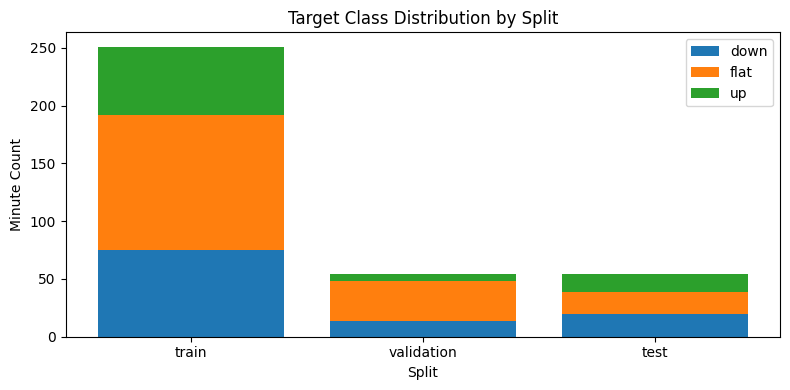

In [16]:
# split target distribution plot

plot_df = split_target_distribution.copy()

splits = ["train", "validation", "test"]
classes = ["down", "flat", "up"]

x_pos = np.arange(len(splits))
bottom = np.zeros(len(splits))

plt.figure(figsize=(8, 4))

for target_class in classes:

    values = []

    for split_name in splits:
        value = plot_df[
            (plot_df["split"] == split_name)
            & (plot_df["target_label"] == target_class)
        ]["count"].iloc[0]

        values.append(value)

    plt.bar(
        x_pos,
        values,
        bottom=bottom,
        label=target_class
    )

    bottom += np.array(values)

plt.xticks(x_pos, splits)

plt.title("Target Class Distribution by Split")
plt.xlabel("Split")
plt.ylabel("Minute Count")
plt.legend()

plt.tight_layout()
plt.show()

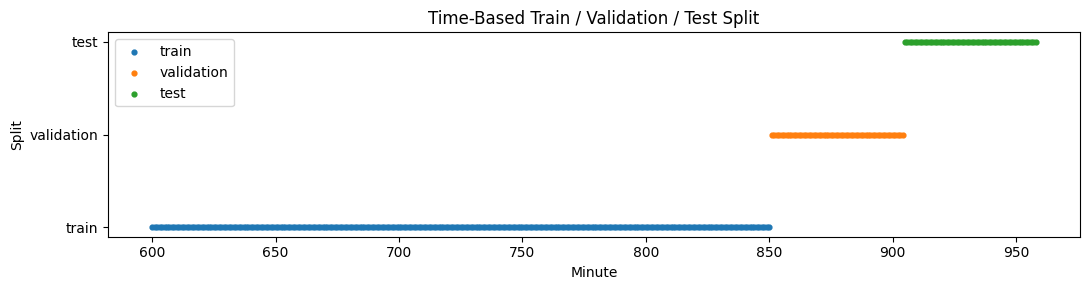

In [17]:
# time-based split visualization

plt.figure(figsize=(11, 3))

plt.scatter(
    train_df["minute"],
    ["train"] * len(train_df),
    s=12,
    label="train"
)

plt.scatter(
    validation_df["minute"],
    ["validation"] * len(validation_df),
    s=12,
    label="validation"
)

plt.scatter(
    test_df["minute"],
    ["test"] * len(test_df),
    s=12,
    label="test"
)

plt.title("Time-Based Train / Validation / Test Split")
plt.xlabel("Minute")
plt.ylabel("Split")
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
# save split indices

SPLIT_DIR = Path("splits")
SPLIT_DIR.mkdir(exist_ok=True)

pd.DataFrame({"index": train_indices}).to_csv(
    SPLIT_DIR / "train_indices.csv",
    index=False
)

pd.DataFrame({"index": validation_indices}).to_csv(
    SPLIT_DIR / "validation_indices.csv",
    index=False
)

pd.DataFrame({"index": test_indices}).to_csv(
    SPLIT_DIR / "test_indices.csv",
    index=False
)

split_metadata = {
    "random_state": RANDOM_STATE,
    "split_type": "time_based",
    "shuffle": False,
    "n_total": int(n_total),
    "train_fraction": TRAIN_FRACTION,
    "validation_fraction": VALIDATION_FRACTION,
    "test_fraction": TEST_FRACTION,
    "train_rows": int(len(train_indices)),
    "validation_rows": int(len(validation_indices)),
    "test_rows": int(len(test_indices)),
    "train_minute_min": int(train_df["minute"].min()),
    "train_minute_max": int(train_df["minute"].max()),
    "validation_minute_min": int(validation_df["minute"].min()),
    "validation_minute_max": int(validation_df["minute"].max()),
    "test_minute_min": int(test_df["minute"].min()),
    "test_minute_max": int(test_df["minute"].max()),
}

with open(SPLIT_DIR / "split_metadata.json", "w", encoding="utf-8") as f:
    json.dump(split_metadata, f, indent=2)

print("Split indices saved:")
print(SPLIT_DIR / "train_indices.csv")
print(SPLIT_DIR / "validation_indices.csv")
print(SPLIT_DIR / "test_indices.csv")
print(SPLIT_DIR / "split_metadata.json")

Split indices saved:
splits/train_indices.csv
splits/validation_indices.csv
splits/test_indices.csv
splits/split_metadata.json


In [19]:
# save final model data and metadata

model_df.to_pickle("model_df.pkl")
model_df.to_csv("model_df.csv", index=False)

with open("model_feature_cols.txt", "w", encoding="utf-8") as f:
    for col in model_feature_cols:
        f.write(col + "\n")

target_metadata = {
    "target_definition": "future_mid_return = mid_close(t+1) - mid_close(t)",
    "target_horizon_minutes": TARGET_HORIZON_MINUTES,
    "tick_size": TICK_SIZE,
    "target_threshold": TARGET_THRESHOLD,
    "threshold_explanation": "1 tick threshold is used. Price changes smaller than 1 tick are labeled as flat.",
    "class_labels": CLASS_LABELS,
    "label_to_id": LABEL_TO_ID,
    "n_rows_before_lag_drop": int(rows_before_drop),
    "n_rows_after_lag_drop": int(rows_after_drop),
    "n_model_features": int(len(model_feature_cols)),
    "lag_windows": LAG_WINDOWS,
    "rolling_windows": ROLLING_WINDOWS,
    "base_signal_cols": base_signal_cols,
    "split_dir": str(SPLIT_DIR)
}

with open("target_metadata.json", "w", encoding="utf-8") as f:
    json.dump(target_metadata, f, indent=2)

print("Saved files:")
print("- model_df.pkl")
print("- model_df.csv")
print("- model_feature_cols.txt")
print("- target_metadata.json")

print("\nmodel_df shape:", model_df.shape)
print("Feature count:", len(model_feature_cols))


Saved files:
- model_df.pkl
- model_df.csv
- model_feature_cols.txt
- target_metadata.json

model_df shape: (359, 793)
Feature count: 784


In [ ]:
# final notebook summary

print("=" * 70)
print("NOTEBOOK 02 SUMMARY")
print("=" * 70)

print("\nInput file:")
print(f"- {MINUTE_FEATURES_FILE}")

print("\nTarget:")
print(f"- Formula: future_mid_return = mid_close(t+1) - mid_close(t)")
print(f"- Horizon: t + {TARGET_HORIZON_MINUTES} minute")
print(f"- Threshold: {TARGET_THRESHOLD:.4f} USD ({TARGET_THRESHOLD / TICK_SIZE:.1f} tick)")
print("- Classes: 0=down, 1=flat, 2=up")

print("\nFeature engineering:")
print(f"- Base signal count: {len(base_signal_cols)}")
print(f"- Lag windows: {LAG_WINDOWS}")
print(f"- Rolling windows: {ROLLING_WINDOWS}")
print(f"- Final model feature count: {len(model_feature_cols)}")

print("\nRows:")
print(f"- Before lag/rolling drop: {rows_before_drop}")
print(f"- After lag/rolling drop : {rows_after_drop}")
print(f"- Dropped rows           : {rows_before_drop - rows_after_drop}")

print("\nTime-based split:")
print(f"- Train      : {len(train_df)} rows | minute {train_df['minute'].min()} → {train_df['minute'].max()}")
print(f"- Validation : {len(validation_df)} rows | minute {validation_df['minute'].min()} → {validation_df['minute'].max()}")
print(f"- Test       : {len(test_df)} rows | minute {test_df['minute'].min()} → {test_df['minute'].max()}")

print("\nSaved files:")
saved_files = [
    "model_df.pkl",
    "model_df.csv",
    "model_feature_cols.txt",
    "target_metadata.json",
    "splits/train_indices.csv",
    "splits/validation_indices.csv",
    "splits/test_indices.csv",
    "splits/split_metadata.json"
]

for file_name in saved_files:
    if Path(file_name).exists():
        print(f"OK - {file_name}")
    else:
        print(f"MISSING - {file_name}")

print("\nNotebook 02 complete.")
print("=" * 70)

NOTEBOOK 02 SUMMARY

Input file:
- minute_features.pkl

Target:
- Formula: future_mid_return = mid_close(t+1) - mid_close(t)
- Horizon: t + 1 minute
- Threshold: 0.0100 USD (1.0 tick)
- Classes: 0=down, 1=flat, 2=up

Feature engineering:
- Base signal count: 28
- Lag windows: [1, 2, 3, 5, 10, 15, 30]
- Rolling windows: [3, 5, 10, 15, 30]
- Final model feature count: 784

Rows:
- Before lag/rolling drop: 389
- After lag/rolling drop : 359
- Dropped rows           : 30

Time-based split:
- Train      : 251 rows | minute 600 → 850
- Validation : 54 rows | minute 851 → 904
- Test       : 54 rows | minute 905 → 958

Saved files:
OK - model_df.pkl
OK - model_df.csv
OK - model_feature_cols.txt
OK - target_metadata.json
OK - splits/train_indices.csv
OK - splits/validation_indices.csv
OK - splits/test_indices.csv
OK - splits/split_metadata.json

Notebook 02 complete.
